In [ ]:
!pip install -q gdown

In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd


import cv2
from PIL import Image


import os
import json
import shutil
from glob import glob
from tqdm import tqdm




print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))


TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## LOAD DATASET

In [ ]:
ROOT_DIR = "/content"

DATASET_DIR = os.path.join(ROOT_DIR, "car_view_dataset")
RAW_ZIP_PATH = os.path.join(ROOT_DIR, "dataset.zip")

os.makedirs(DATASET_DIR, exist_ok=True)

print("Dataset directory ready:", DATASET_DIR)

Dataset directory ready: /content/car_view_dataset


In [ ]:
dataset_link = "https://drive.google.com/file/d/12dXSLNwbArubn25XjcMBd-Pqw7go4ShN/view"

In [ ]:
import gdown

DATASET_FILE_ID = "12dXSLNwbArubn25XjcMBd-Pqw7go4ShN"

gdown.download(
    id=DATASET_FILE_ID,
    output=RAW_ZIP_PATH,
    quiet=False
)

print("Download completed:", os.path.exists(RAW_ZIP_PATH))


In [ ]:
import zipfile

with zipfile.ZipFile(RAW_ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall(DATASET_DIR)

print("Dataset extracted successfully")

Dataset extracted successfully


In [ ]:
image_files = glob(DATASET_DIR + "/**/*.jpg", recursive=True) + \
              glob(DATASET_DIR + "/**/*.png", recursive=True)

json_files = glob(DATASET_DIR + "/**/*.json", recursive=True)

print(f"Total images found: {len(image_files)}")
print(f"Total annotation json files found: {len(json_files)}")

In [ ]:
DATASET_DIR = "/content/car_view_dataset"

In [ ]:
import json

file_path = '/content/car_view_dataset/exercise_1/5e9112c35026365e15eb871b/via_region_data.json'
with open(file_path, 'r') as f:
    data = json.load(f)


sample_keys = list(data.keys())[:1]
sample_labels = {key: data[key] for key in sample_keys}


formatted_samples = json.dumps(sample_labels, indent=2)
print(formatted_samples)

{
  "IMG_20200219_170506_1586530497634.jpeg": {
    "filename": "IMG_20200219_170506_1586530497634.jpeg",
    "size": 0,
    "regions": [
      {
        "shape_attributes": {
          "name": "polygon",
          "all_points_x": [
            356,
            340,
            324,
            308,
            293,
            277,
            263,
            248,
            235,
            222,
            210,
            197,
            185,
            174,
            172,
            171,
            173,
            175,
            175,
            174,
            176,
            176,
            179,
            179,
            179,
            179,
            182,
            183,
            184,
            185,
            186,
            187,
            190,
            191,
            193,
            195,
            197,
            198,
            200,
            209,
            223,
            238,
            253,
            269,
            284,
  

# VISUALIZE FEW DATA

In [ ]:
import random
import matplotlib.pyplot as plt

In [ ]:
def polygon_to_bbox(all_x, all_y):
    xmin = min(all_x)
    xmax = max(all_x)
    ymin = min(all_y)
    ymax = max(all_y)
    return xmin, ymin, xmax, ymax

In [ ]:
ANNOTATION_DIR = DATASET_DIR
annotation_files = []

for root, _, files in os.walk(ANNOTATION_DIR):
    for file in files:
        if file.endswith(".json"):
            annotation_files.append(os.path.join(root, file))

print(f"Total annotation files found: {len(annotation_files)}")
sample_jsons = random.sample(annotation_files, 4)

Total annotation files found: 61


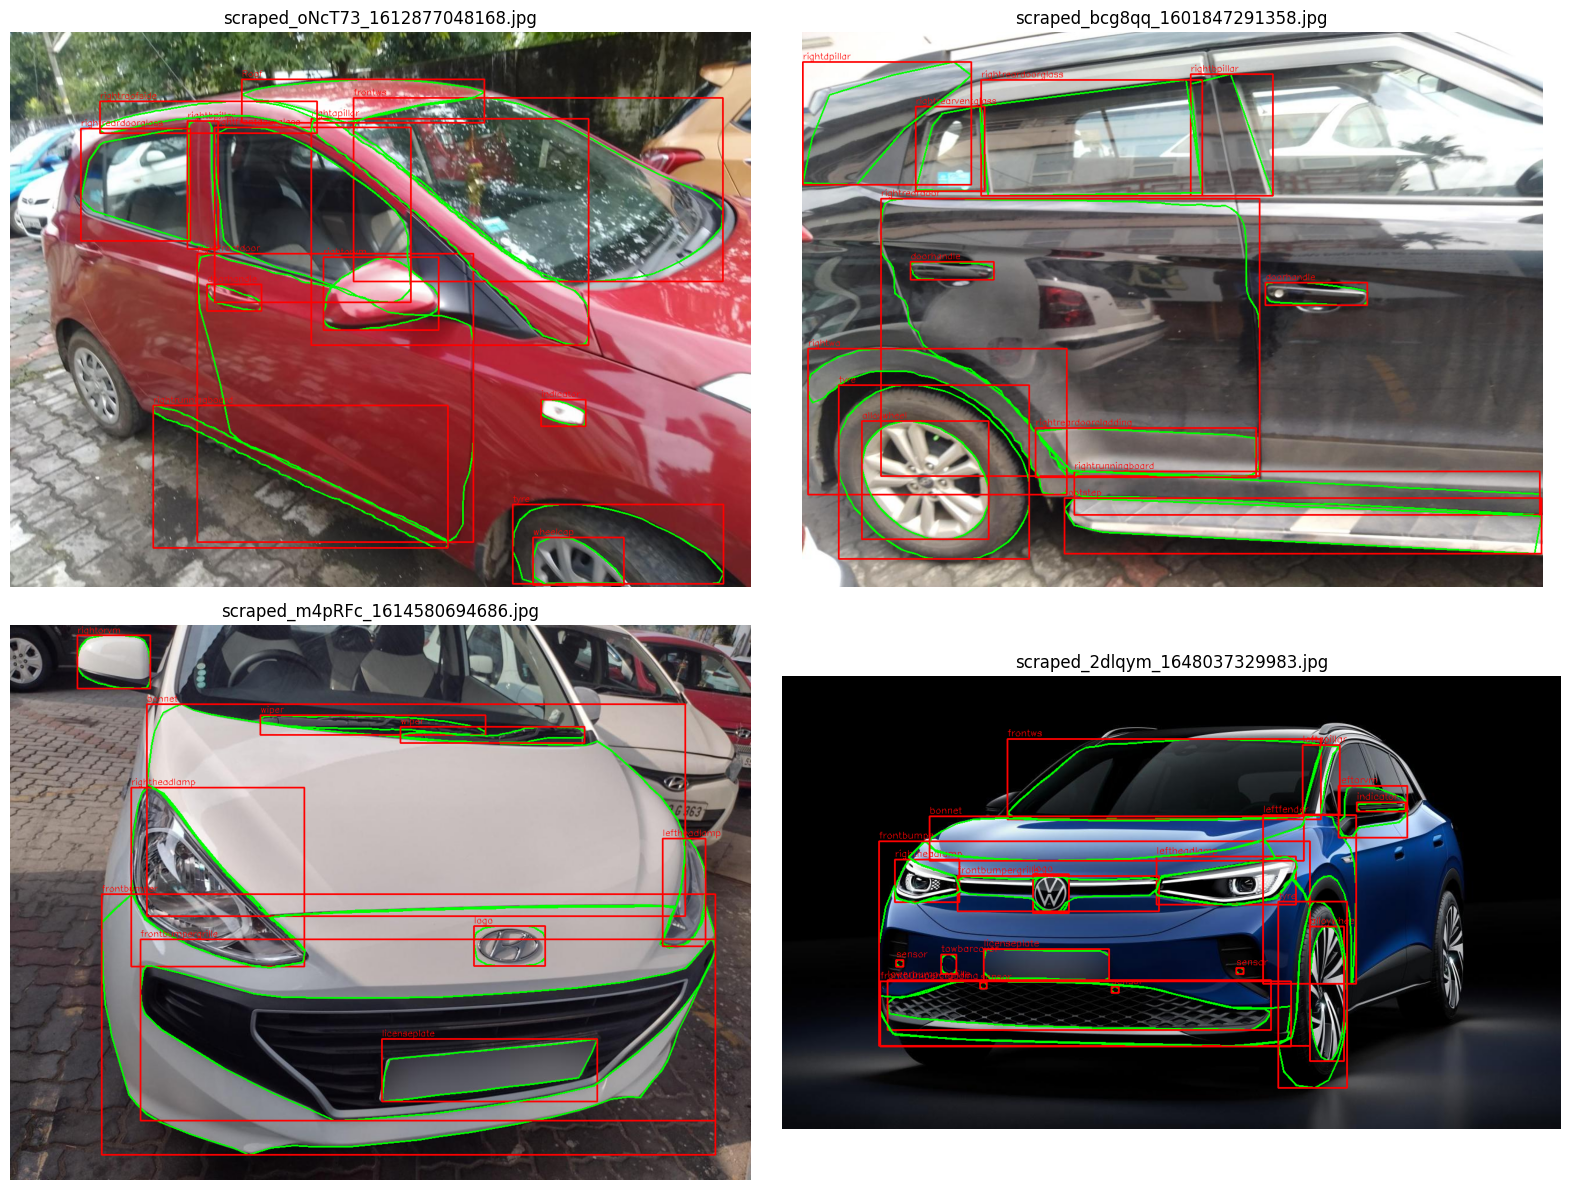

In [ ]:
plt.figure(figsize=(16, 12))

for idx, json_path in enumerate(sample_jsons):
    with open(json_path, "r") as f:
        data = json.load(f)


    image_key = list(data.keys())[0]
    record = data[image_key]

    image_name = record["filename"]

    image_path = None
    for root, _, files in os.walk(DATASET_DIR):
        if image_name in files:
            image_path = os.path.join(root, image_name)
            break

    if image_path is None:
        print(f"Image not found: {image_name}")
        continue

    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    for region in record["regions"]:
        shape = region["shape_attributes"]
        identity = region["region_attributes"].get("identity", "unknown")

        all_x = shape["all_points_x"]
        all_y = shape["all_points_y"]

        polygon = list(zip(all_x, all_y))
        cv2.polylines(
            image,
            [np.array(polygon, np.int32)],
            isClosed=True,
            color=(0, 255, 0),
            thickness=2
        )

        xmin, ymin, xmax, ymax = polygon_to_bbox(all_x, all_y)
        cv2.rectangle(
            image,
            (int(xmin), int(ymin)),
            (int(xmax), int(ymax)),
            (255, 0, 0),
            2
        )

        cv2.putText(
            image,
            identity,
            (int(xmin), max(int(ymin) - 5, 15)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (255, 0, 0),
            1
        )

    plt.subplot(2, 2, idx + 1)
    plt.imshow(image)
    plt.title(image_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

# PREPROCESSING DATASET

In [ ]:
CACHE_DIR = "/content/preprocessed_cache"
os.makedirs(CACHE_DIR, exist_ok=True)

CACHE_FILE = os.path.join(CACHE_DIR, "car_view_data.npz")


In [ ]:
import os
import json
import cv2
import gc
import numpy as np
from tqdm import tqdm
from sklearn.model_selection import train_test_split


IMG_SIZE = 224

CLASS_NAMES = [
    "front",
    "frontleft",
    "frontright",
    "rear",
    "rearleft",
    "rearright",
    "unknown"
]

CLASS_TO_ID = {cls: idx for idx, cls in enumerate(CLASS_NAMES)}


CACHE_DIR = "/content/preprocessed_cache"
os.makedirs(CACHE_DIR, exist_ok=True)

CACHE_FILE = os.path.join(CACHE_DIR, "car_view_data.npz")


LEFT_REAR_PARTS = {
    "lefttaillamp",
    "lefttailgate"
}

RIGHT_REAR_PARTS = {
    "righttaillamp",
    "righttailgate"
}


def infer_image_label(part_identities: set) -> str:
    """
    Convert polygon identities → ONE image-level label
    (Aligned with real dataset identities)
    """


    if "frontws" in part_identities:
        if "rightapillar" in part_identities:
            return "frontright"
        if "leftapillar" in part_identities:
            return "frontleft"
        return "front"


    if "rearws" in part_identities:
        if part_identities.intersection(RIGHT_REAR_PARTS):
            return "rearright"
        if part_identities.intersection(LEFT_REAR_PARTS):
            return "rearleft"
        return "rear"

    return "unknown"


if os.path.exists(CACHE_FILE):
    print("✅ Loading cached preprocessed dataset...")

    cache = np.load(CACHE_FILE)
    X_train = cache["X_train"]
    X_val   = cache["X_val"]
    y_train = cache["y_train"]
    y_val   = cache["y_val"]

    print("✅ Cache loaded successfully")
    print("Train samples:", len(X_train))
    print("Validation samples:", len(X_val))

else:
    print("⚙️ Cache not found → preprocessing dataset...")

    images = []
    labels = []

    for json_path in tqdm(annotation_files, desc="Processing annotations"):
        with open(json_path, "r") as f:
            data = json.load(f)

        for _, record in data.items():
            image_name = record.get("filename")
            if not image_name:
                continue


            image_path = None
            for root, _, files in os.walk(DATASET_DIR):
                if image_name in files:
                    image_path = os.path.join(root, image_name)
                    break

            if image_path is None:
                continue


            part_ids = set()
            for region in record.get("regions", []):
                identity = region.get("region_attributes", {}).get("identity")
                if identity:
                    part_ids.add(identity.lower())

            label_name = infer_image_label(part_ids)
            label_id = CLASS_TO_ID[label_name]

            img = cv2.imread(image_path)
            if img is None:
                continue

            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            img = img.astype(np.float32) / 255.0

            images.append(img)
            labels.append(label_id)

    X = np.asarray(images, dtype=np.float32)
    y = np.asarray(labels, dtype=np.int64)

    print("\n📊 Dataset Summary")
    print("Total samples:", len(X))
    for cls, idx in CLASS_TO_ID.items():
        print(f"{cls}: {(y == idx).sum()}")


    X_train, X_val, y_train, y_val = train_test_split(
        X,
        y,
        test_size=0.2,
        stratify=y,
        random_state=42
    )


    np.savez_compressed(
        CACHE_FILE,
        X_train=X_train,
        X_val=X_val,
        y_train=y_train,
        y_val=y_val
    )

    print("\n💾 Preprocessed dataset cached successfully")
    print("Train samples:", len(X_train))
    print("Validation samples:", len(X_val))


    del X, y, images, labels
    gc.collect()


⚙️ Cache not found → preprocessing dataset...


Processing annotations: 100%|██████████| 61/61 [00:37<00:00,  1.62it/s]



📊 Dataset Summary
Total samples: 3974
front: 277
frontleft: 508
frontright: 400
rear: 29
rearleft: 211
rearright: 507
unknown: 2042

💾 Preprocessed dataset cached successfully
Train samples: 3179
Validation samples: 795


# BUILD MODEL AND TRAINING

In [ ]:
from tensorflow.keras import layers, models
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

NUM_CLASSES = len(CLASS_TO_ID)

valid_classes = [i for i in range(NUM_CLASSES) if np.sum(y_train == i) > 0]

print("Training on class IDs:", valid_classes)

class_weights_raw = compute_class_weight(
    class_weight="balanced",
    classes=np.array(valid_classes),
    y=y_train[np.isin(y_train, valid_classes)]
)

class_weights = {
    cls: weight for cls, weight in zip(valid_classes, class_weights_raw)
}

print("Class weights:", class_weights)

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

inputs = layers.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = models.Model(inputs, outputs)

Training on class IDs: [0, 1, 2, 3, 4, 5, 6]
Class weights: {0: np.float64(2.0456885456885456), 1: np.float64(1.1185784658691063), 2: np.float64(1.4191964285714285), 3: np.float64(19.74534161490683), 4: np.float64(2.687235841081995), 5: np.float64(1.1185784658691063), 6: np.float64(0.27810340302685677)}


In [ ]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,427,975 (9.26 MB)

 Trainable params: 167,431 (654.03 KB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=[
        tf.keras.metrics.SparseCategoricalAccuracy(name="accuracy")
    ]
)

In [ ]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=3,
        min_lr=1e-6
    )
]

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 49s 307ms/step - accuracy: 0.4076 - loss: 1.9863 - val_accuracy: 0.6101 - val_loss: 1.0162 - learning_rate: 0.0010
Epoch 2/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - accuracy: 0.6444 - loss: 0.9031 - val_accuracy: 0.6893 - val_loss: 0.8516 - learning_rate: 0.0010
Epoch 3/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - accuracy: 0.7301 - loss: 0.6645 - val_accuracy: 0.7145 - val_loss: 0.7527 - learning_rate: 0.0010
Epoch 4/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - accuracy: 0.8162 - loss: 0.4248 - val_accuracy: 0.7208 - val_loss: 0.7519 - learning_rate: 0.0010
Epoch 5/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - accuracy: 0.8345 - loss: 0.3901 - val_accuracy: 0.7346 - val_loss: 0.7144 - learning_rate: 0.0010
Epoch 6/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - accuracy: 0.8789 - loss: 0.2915 - val_accuracy: 0.7547 - val_loss: 0.7087 - learning_rate: 0.0010
Epoch 7/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - accuracy: 0.8906 - loss: 

# FINE TUNE MODEL

We froze most of MobileNetV2 and fine-tuned only the last convolutional blocks with a reduced learning rate to adapt domain-specific features while preventing overfitting.

In [ ]:
FINE_TUNE_LAYERS = 30

for layer in base_model.layers:
    layer.trainable = False

for layer in base_model.layers[-FINE_TUNE_LAYERS:]:
    if not isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = True

print(f"Unfroze last {FINE_TUNE_LAYERS} layers of MobileNetV2")

Unfroze last 30 layers of MobileNetV2


In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=[
        tf.keras.metrics.SparseCategoricalAccuracy(name="accuracy")
    ]
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,427,975 (9.26 MB)

 Trainable params: 1,678,151 (6.40 MB)

 Non-trainable params: 749,824 (2.86 MB)

In [ ]:
fine_tune_epochs = 15

history_finetune = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=fine_tune_epochs,
    batch_size=32,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 31s 190ms/step - accuracy: 0.8596 - loss: 0.3832 - val_accuracy: 0.5799 - val_loss: 2.4567 - learning_rate: 1.0000e-04
Epoch 2/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - accuracy: 0.7853 - loss: 0.7363 - val_accuracy: 0.7723 - val_loss: 0.9436 - learning_rate: 1.0000e-04
Epoch 3/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - accuracy: 0.8680 - loss: 0.2852 - val_accuracy: 0.7346 - val_loss: 0.8304 - learning_rate: 1.0000e-04
Epoch 4/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step - accuracy: 0.9153 - loss: 0.1389 - val_accuracy: 0.7761 - val_loss: 0.7359 - learning_rate: 1.0000e-04
Epoch 5/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - accuracy: 0.9527 - loss: 0.0946 - val_accuracy: 0.8151 - val_loss: 0.6262 - learning_rate: 1.0000e-04
Epoch 6/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step - accuracy: 0.9649 - loss: 0.0621 - val_accuracy: 0.8390 - val_loss: 0.5157 - learning_rate: 1.0000e-04
Epoch 7/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - a

# EVALUATE MODEL PERFORMANCE

In [ ]:
import numpy as np

y_pred_probs = model.predict(X_val, batch_size=32, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)

25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 181ms/step


In [ ]:
from sklearn.metrics import classification_report

target_names = [cls for cls in CLASS_NAMES]

print(
    classification_report(
        y_val,
        y_pred,
        target_names=target_names,
        digits=4,
        zero_division=0
    )
)


              precision    recall  f1-score   support

       front     0.7586    0.8000    0.7788        55
   frontleft     0.8868    0.9216    0.9038       102
  frontright     0.8642    0.8750    0.8696        80
        rear     0.2500    0.1667    0.2000         6
    rearleft     0.7727    0.8095    0.7907        42
   rearright     0.8286    0.8614    0.8447       101
     unknown     0.9421    0.9144    0.9280       409

    accuracy                         0.8855       795
   macro avg     0.7576    0.7641    0.7594       795
weighted avg     0.8859    0.8855    0.8854       795



In [ ]:
from sklearn.metrics import f1_score

f1_macro = f1_score(y_val, y_pred, average="macro")
f1_weighted = f1_score(y_val, y_pred, average="weighted")

print(f"F1 Macro    : {f1_macro:.4f}")
print(f"F1 Weighted : {f1_weighted:.4f}")


F1 Macro    : 0.7594
F1 Weighted : 0.8854


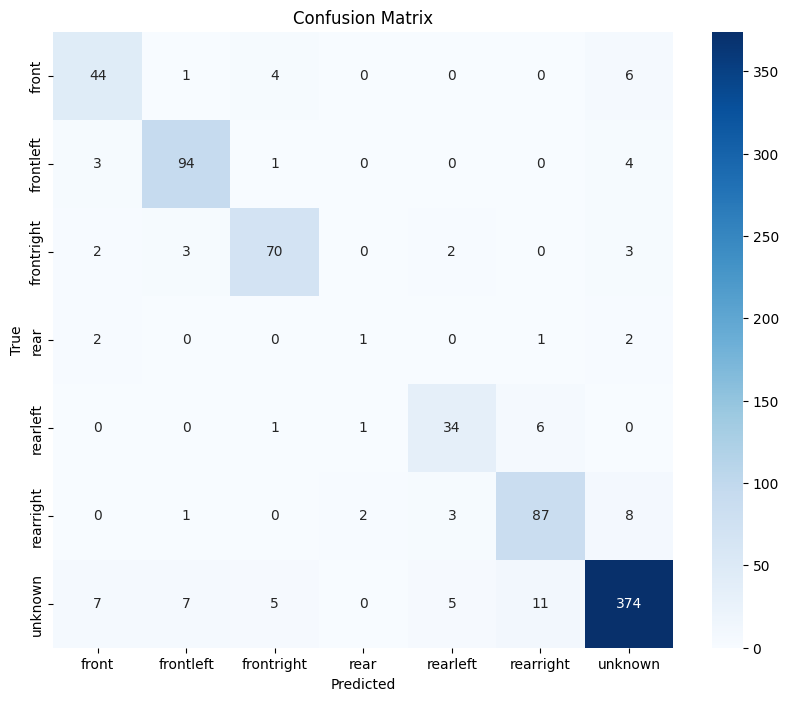

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


# PREDICT MODEL PERFORMANCE

In [ ]:
import random
ID_TO_CLASS = {v: k for k, v in CLASS_TO_ID.items()}
def evaluate_random_samples(X_val, y_val, model, n=8):
    indices = random.sample(range(len(X_val)), n)

    plt.figure(figsize=(16, 8))
    for i, idx in enumerate(indices):
        img = X_val[idx]
        true_label = ID_TO_CLASS[y_val[idx]]

        pred = model.predict(img[None, ...], verbose=0)
        pred_label = ID_TO_CLASS[np.argmax(pred)]
        conf = np.max(pred)

        plt.subplot(2, 4, i + 1)
        plt.imshow(img)
        plt.title(f"T: {true_label}\nP: {pred_label} ({conf:.2f})")
        plt.axis("off")

    plt.tight_layout()
    plt.show()


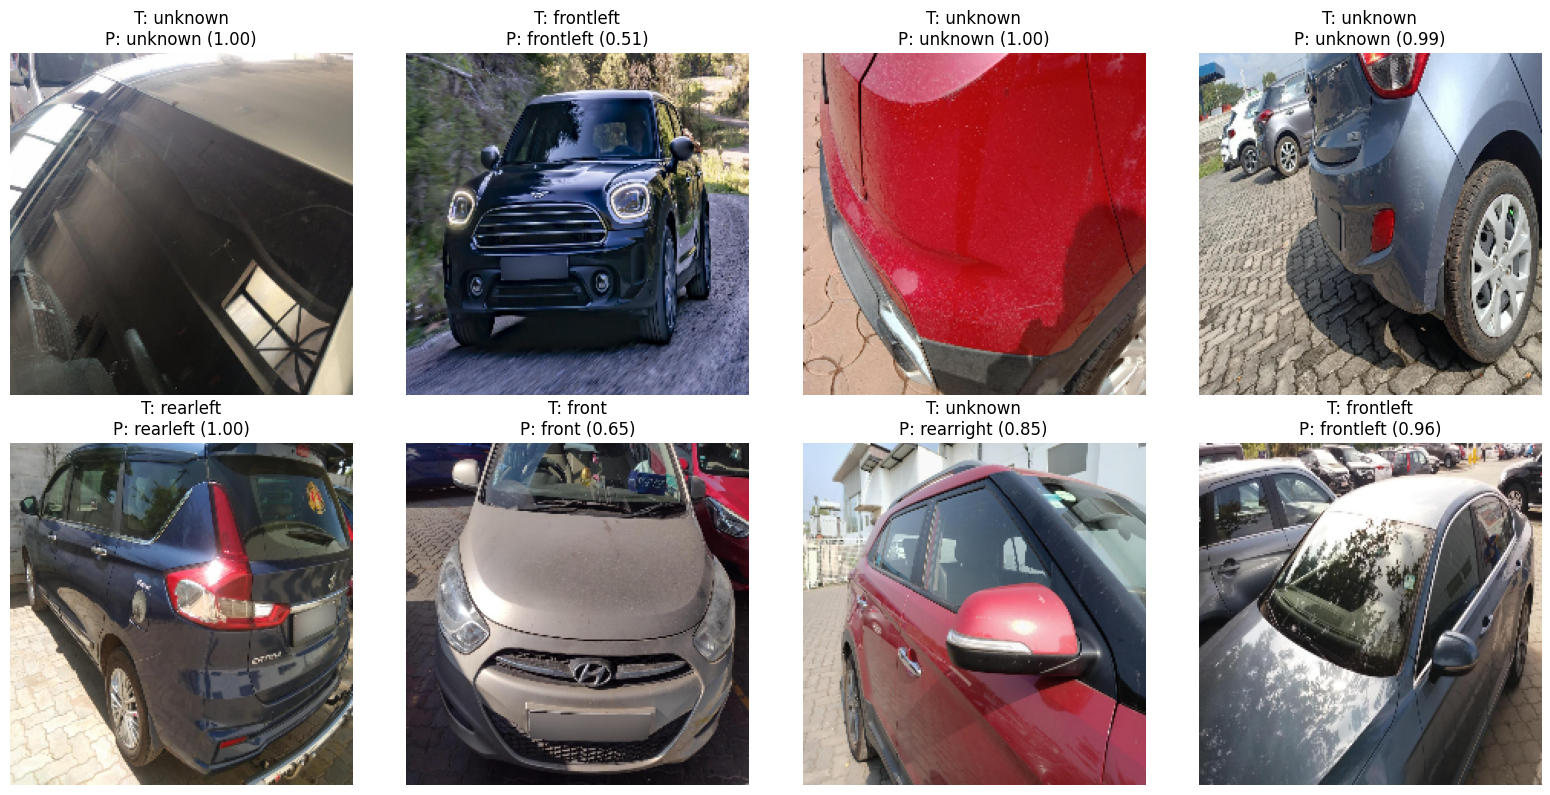

In [ ]:
evaluate_random_samples(X_val, y_val, model)


#TFLite Conversion & Optimization

In [ ]:
MODEL_DIR = "/content/model_export"
os.makedirs(MODEL_DIR, exist_ok=True)

keras_model_path = os.path.join(MODEL_DIR, "car_view_classifier.h5")
model.save(keras_model_path)

print("Keras model saved at:", keras_model_path)

Keras model saved at: /content/model_export/car_view_classifier.h5


In [ ]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = []
tflite_model = converter.convert()

tflite_path = os.path.join(MODEL_DIR, "car_view_fp32.tflite")
with open(tflite_path, "wb") as f:
    f.write(tflite_model)

print("FP32 TFLite model saved at:", tflite_path)

In [ ]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_types = [tf.float16]

tflite_fp16 = converter.convert()

tflite_fp16_path = os.path.join(MODEL_DIR, "car_view_fp16.tflite")
with open(tflite_fp16_path, "wb") as f:
    f.write(tflite_fp16)

print("FP16 TFLite model saved at:", tflite_fp16_path)

In [8]:
CLASS_NAMES = [
    "front",
    "frontleft",
    "frontright",
    "rear",
    "rearleft",
    "rearright",
    "unknown"
]

CLASS_TO_ID = {cls: idx for idx, cls in enumerate(CLASS_NAMES)}
ID_TO_CLASS = {v: k for k, v in CLASS_TO_ID.items()}

In [6]:
import numpy as np
import cv2

interpreter = tf.lite.Interpreter(model_path="/content/model_export/car_view_fp16.tflite")
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

def tflite_predict(image_path):
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224))
    img = img.astype(np.float32) / 255.0
    img = np.expand_dims(img, axis=0)

    interpreter.set_tensor(input_details[0]['index'], img)
    interpreter.invoke()

    output = interpreter.get_tensor(output_details[0]['index'])
    pred_id = np.argmax(output)
    confidence = output[0][pred_id]

    return ID_TO_CLASS[pred_id], confidence


In [14]:
label, conf = tflite_predict("/content/predict2.jpg")
print(f"Prediction: {label}, Confidence: {conf:.2f}")

Prediction: rearright, Confidence: 0.97
